In [1]:

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import confusion_matrix

import warnings

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 

from sklearn.datasets import load_breast_cancer

import pandas as pd

# Set random seed to 42 so results are the same every time we run the code
# np.random.seed(42)
# Print a line of 80 equal signs
# print("=" * 80)
# # Print the project title
# print("NEURAL NETWORK FROM SCRATCH - PROJECT IMPLEMENTATION")
# # Print another line of 80 equal signs
# print("=" * 80)

# **Section 1**
## **Dataset Selection — Breast Cancer Wisconsin (Diagnostic) (Classification)**

In [2]:

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **Section 2: Data Understanding and Preprocessing Requirements**

## **Requirement 2.1: Features Identification and Summary**

In [3]:
# Improved Feature Summary Table
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': [df[col].dtype for col in df.columns],
    'Total Values': [df[col].count() for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Missing Values': [df[col].isnull().sum() for col in df.columns],
    'Sample Value': [df[col].iloc[0] for col in df.columns],
    'Min Value': [df[col].min() for col in df.columns],
    'Max Value': [df[col].max() for col in df.columns],
    'Mean': [df[col].mean() for col in df.columns],
    'Median': [df[col].median() for col in df.columns],
    'Std Dev': [df[col].std() for col in df.columns],
    'Variance': [df[col].var() for col in df.columns]
})

# Display the enhanced summary table
feature_summary


,Feature,Data Type,Total Values,Unique Values,Missing Values,Sample Value,Min Value,Max Value,Mean,Median,Std Dev,Variance
0,mean radius,float64,569,456,0,17.990000,6.981000,28.11000,14.127292,13.370000,3.524049,12.418920
1,mean texture,float64,569,479,0,10.380000,9.710000,39.28000,19.289649,18.840000,4.301036,18.498909
2,mean perimeter,float64,569,522,0,122.800000,43.790000,188.50000,91.969033,86.240000,24.298981,590.440480
3,mean area,float64,569,539,0,1001.000000,143.500000,2501.00000,654.889104,551.100000,351.914129,123843.554318
4,mean smoothness,float64,569,474,0,0.118400,0.052630,0.16340,0.096360,0.095870,0.014064,0.000198
5,mean compactness,float64,569,537,0,0.277600,0.019380,0.34540,0.104341,0.092630,0.052813,0.002789
6,mean concavity,float64,569,537,0,0.300100,0.000000,0.42680,0.088799,0.061540,0.079720,0.006355
7,mean concave points,float64,569,542,0,0.147100,0.000000,0.20120,0.048919,0.033500,0.038803,0.001506
8,mean symmetry,float64,569,432,0,0.241900,0.106000,0.30400,0.181162,0.179200,0.027414,0.000752
9,mean fractal dimension,float64,569,499,0,0.078710,0.049960,0.09744,0.062798,0.061540,0.007060,0.000050


# **Section 2**
## **Requirement 2.2: Visual Data Exploration**

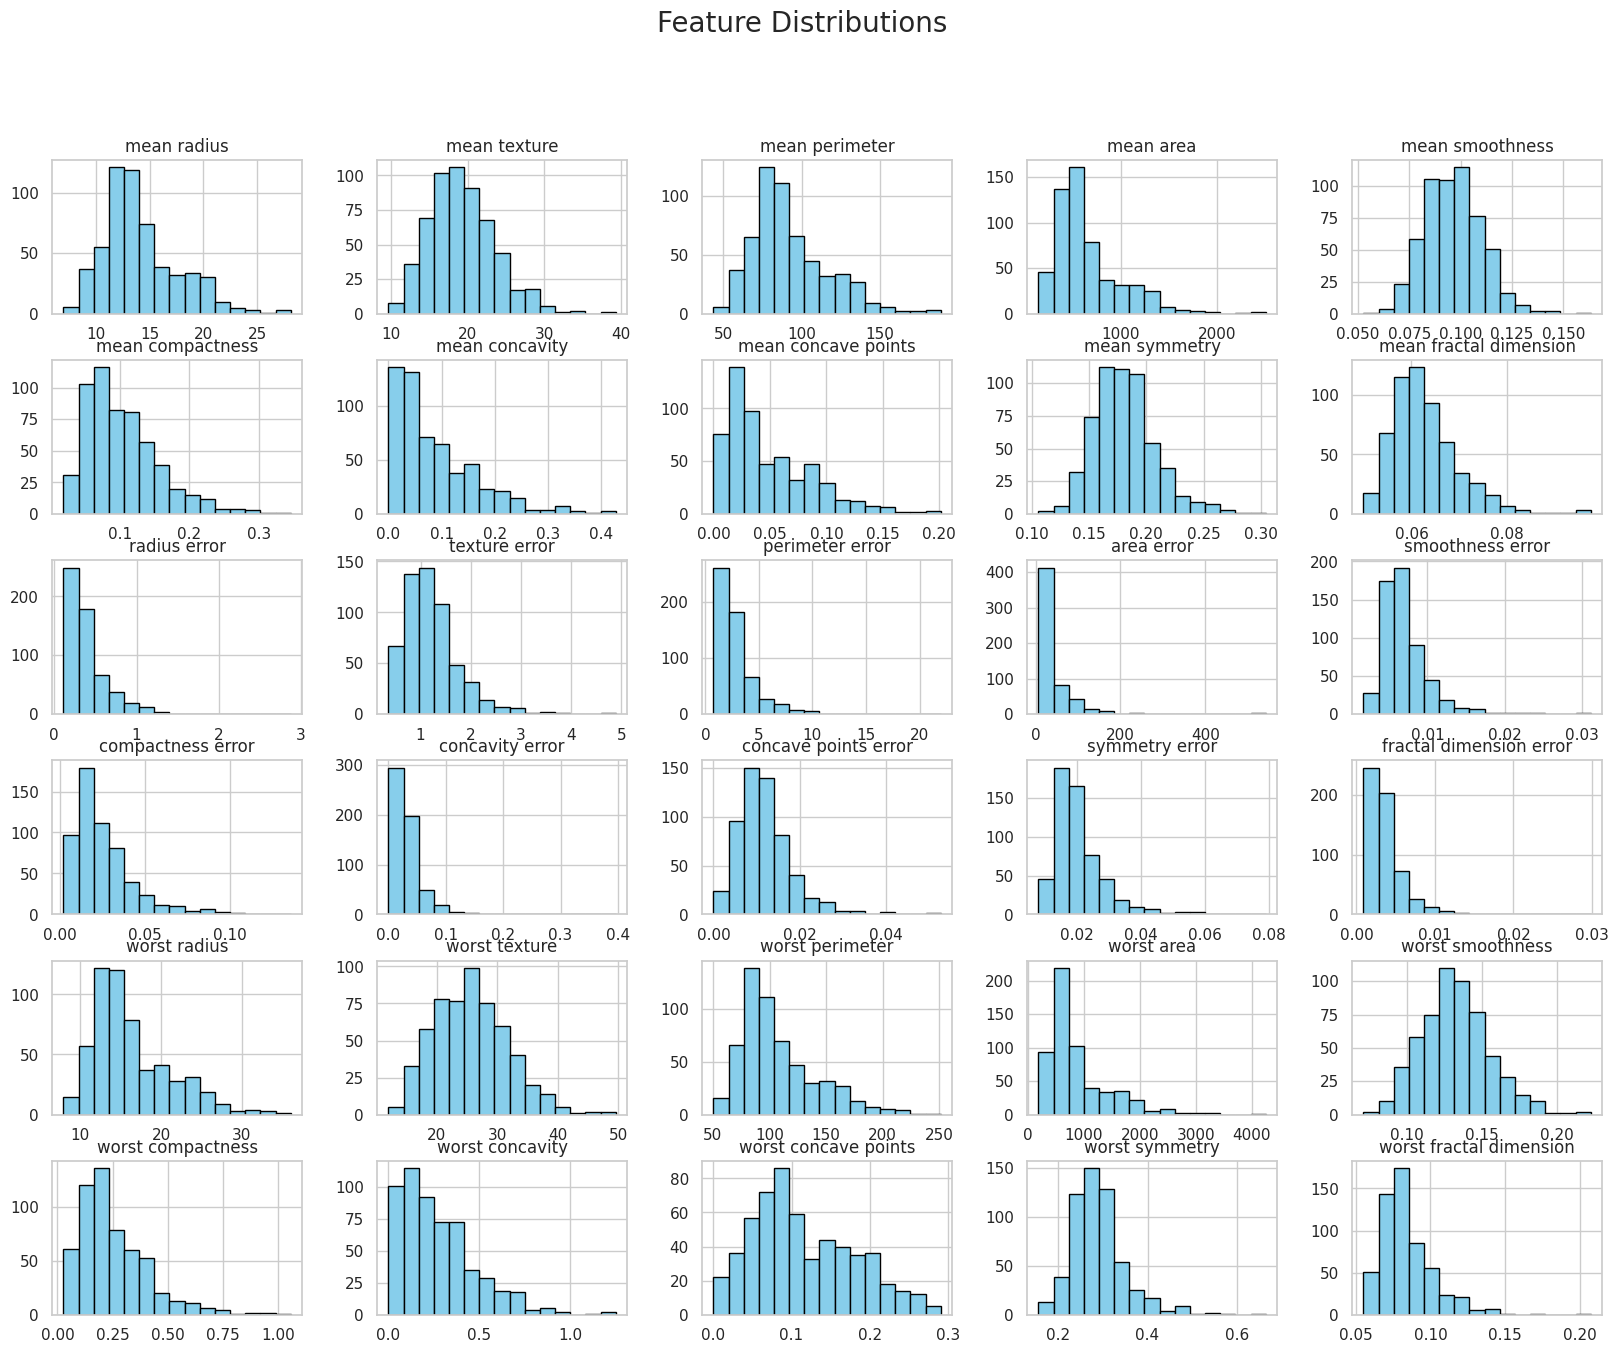

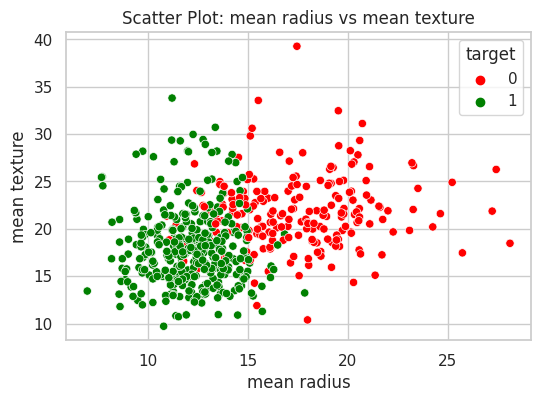

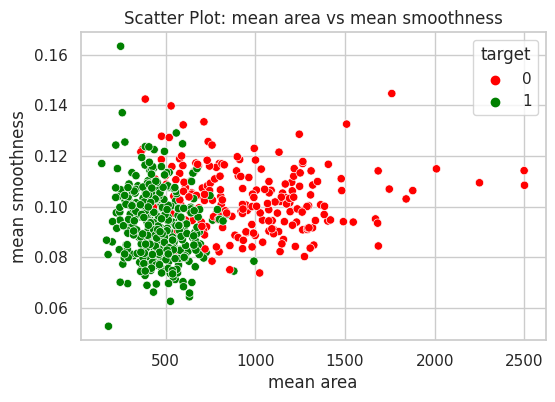

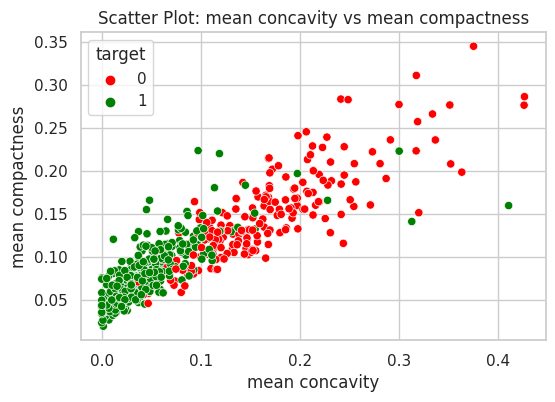

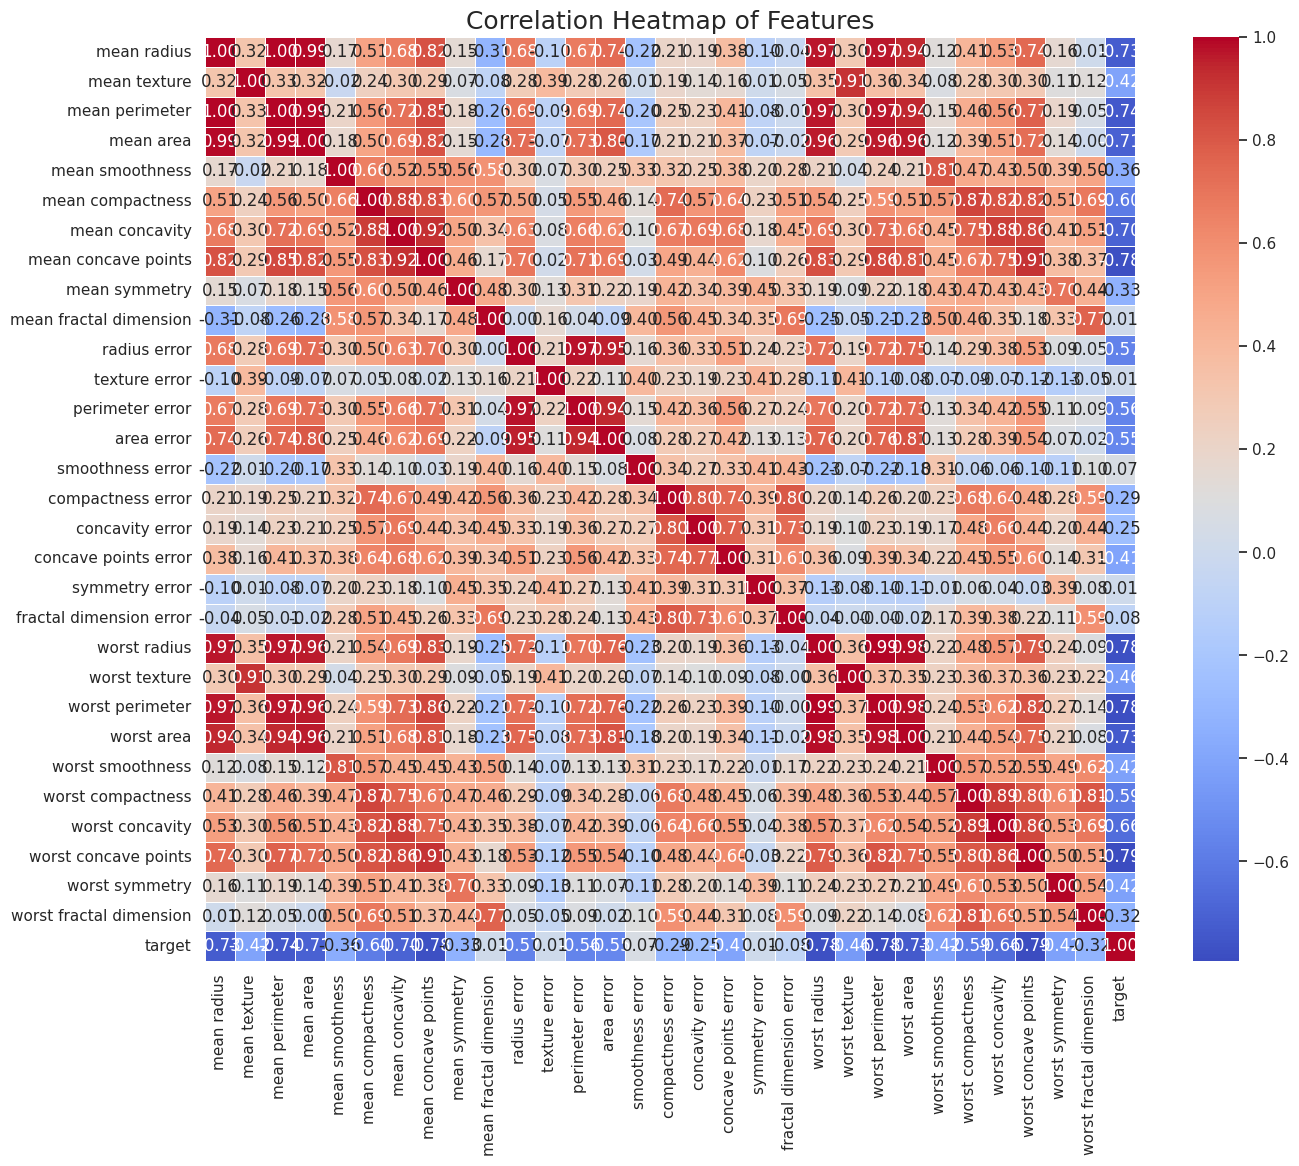

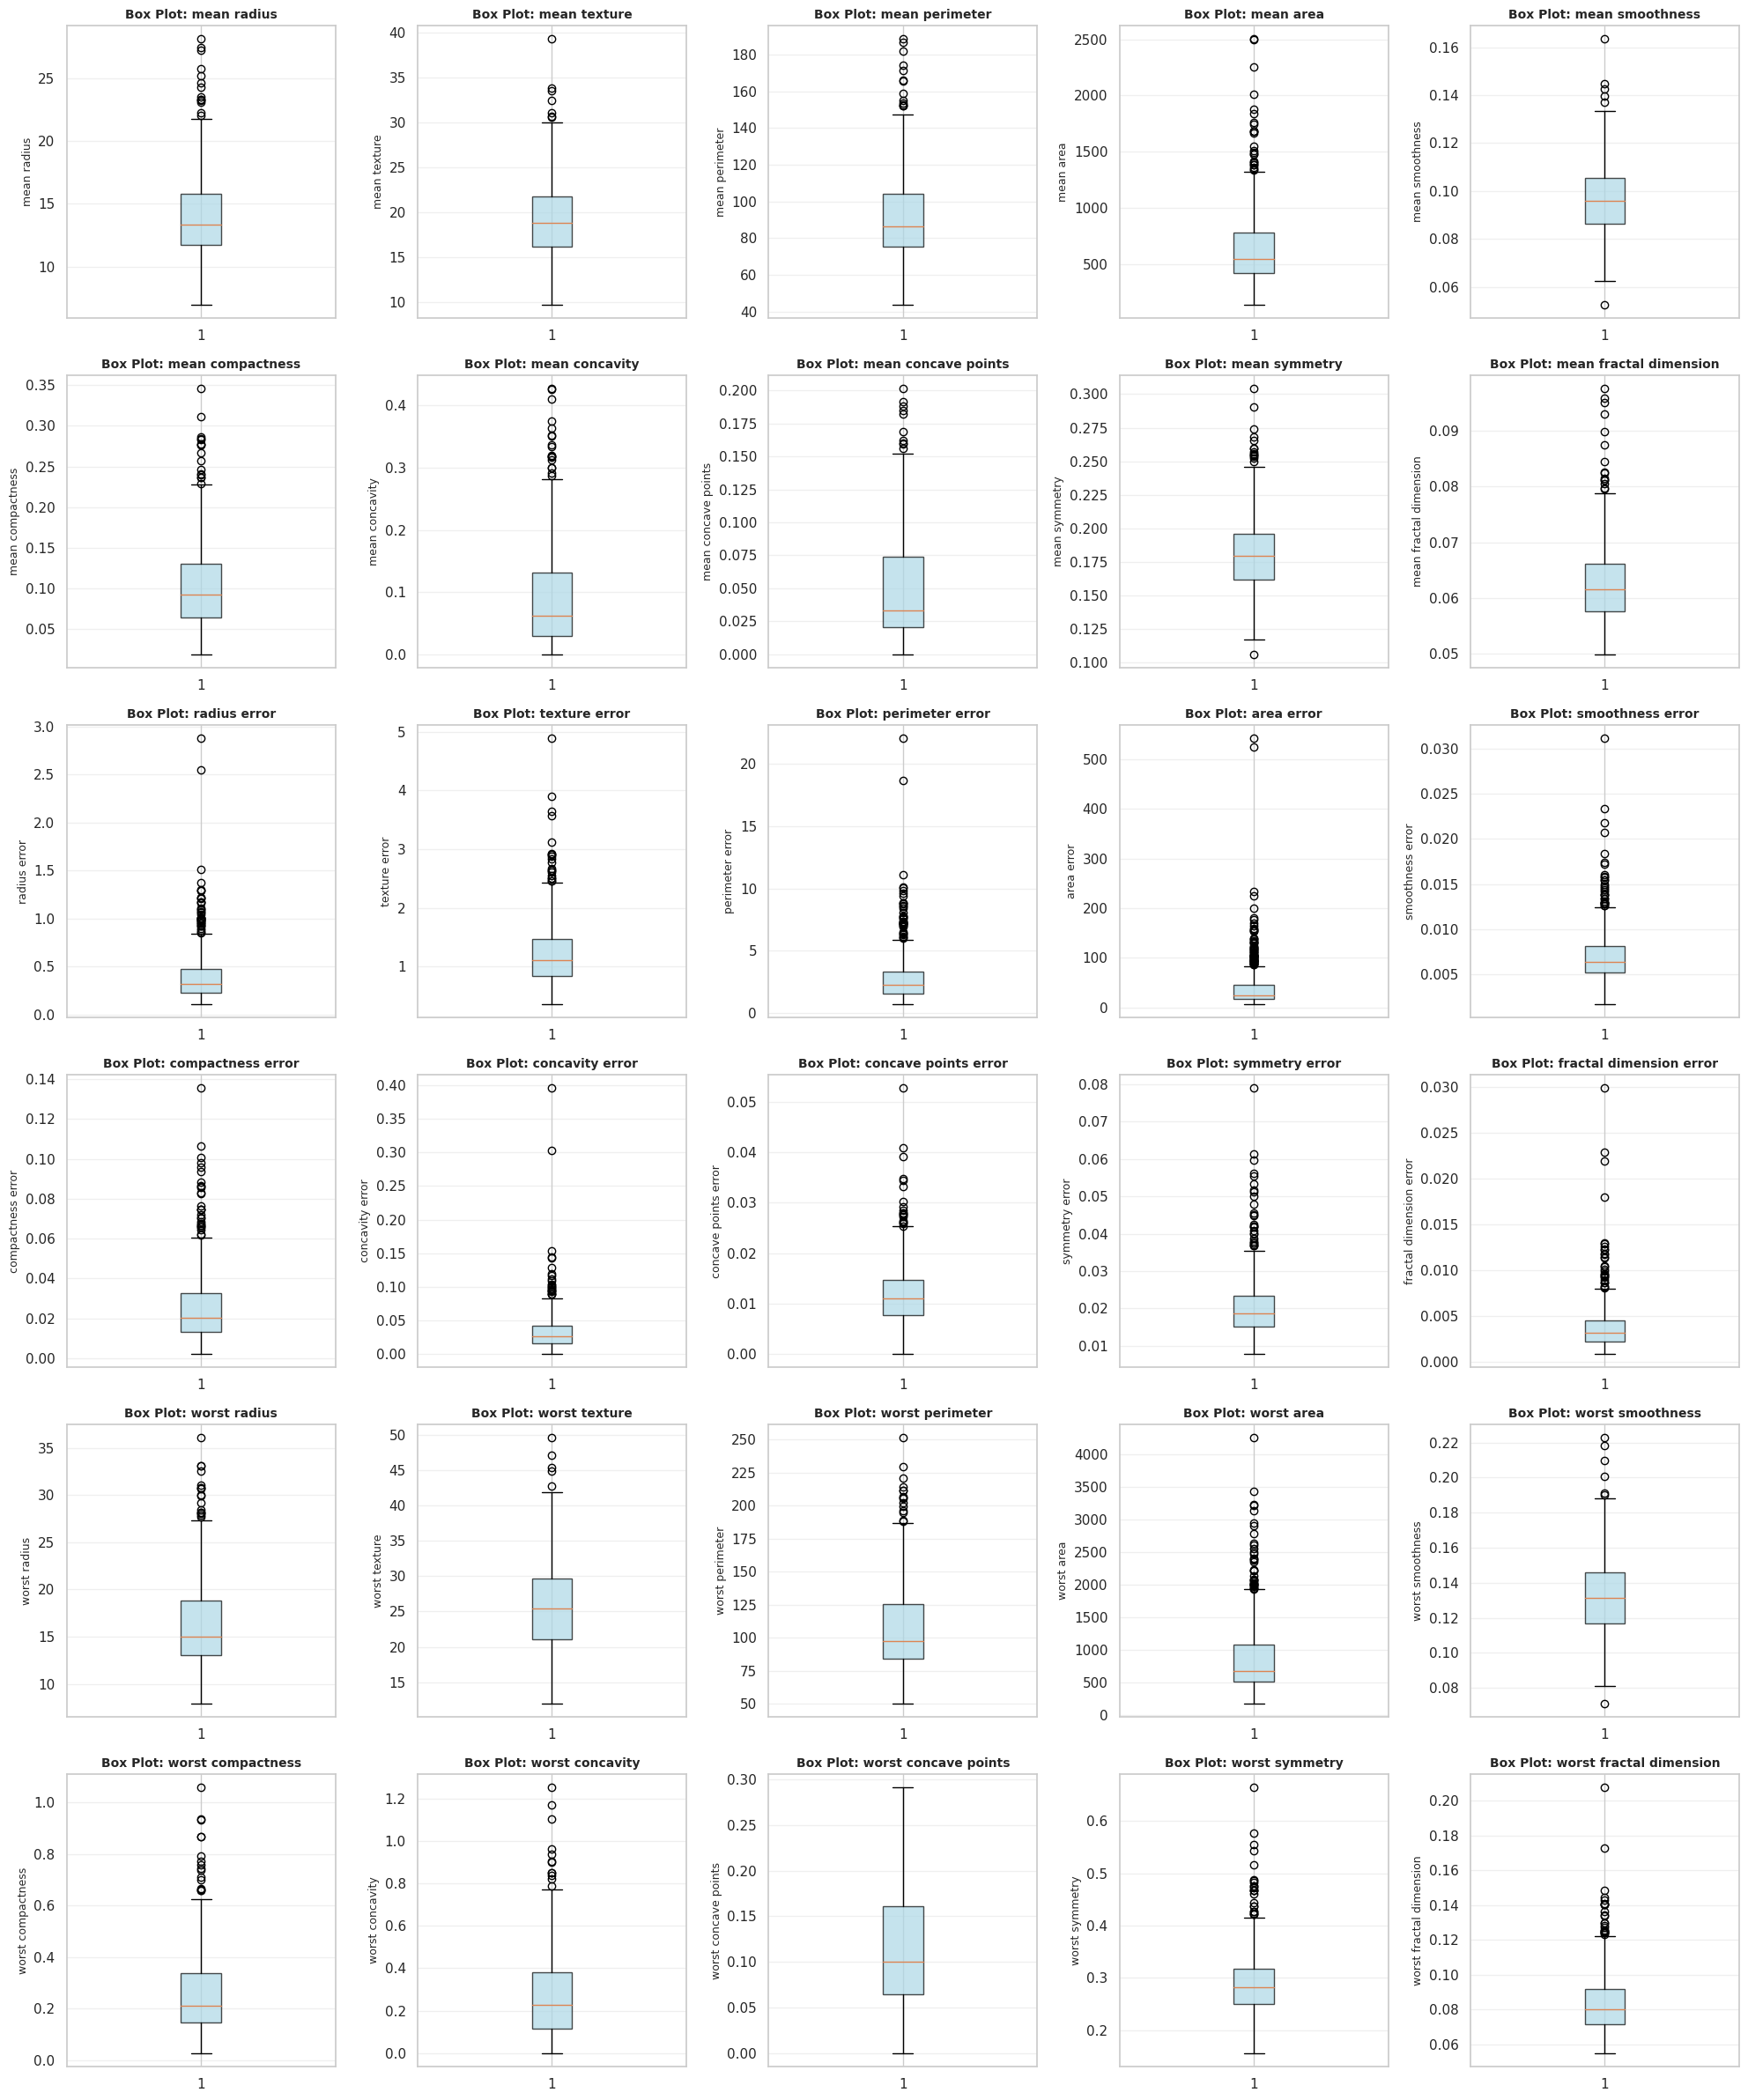

In [8]:
df_copy = df.copy()


sns.set(style="whitegrid")

#drop target because these visualizations are to show the distribution and patterns of the input features.

# 1 Histograms for all features
df_features = df_copy.drop(columns='target')  # Exclude target for histograms
df_features.hist(bins=15, figsize=(20, 15), layout=(6, 5), color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=20)
plt.show()

# 2. Scatter plots for selected feature pairs
feature_pairs = [('mean radius', 'mean texture'), ('mean area', 'mean smoothness'), ('mean concavity', 'mean compactness')]
for x_feat, y_feat in feature_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x_feat, y=y_feat, hue='target', palette={0: 'red', 1: 'green'})
    plt.title(f'Scatter Plot: {x_feat} vs {y_feat}')
    plt.show()

# 3 Correlation heatmap
plt.figure(figsize=(15, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=18)
plt.show()

# 4 boxplot 
# Selecting numeric columns (all features except target)
numerical_cols = df_copy.drop(columns='target').columns
n_plots = len(numerical_cols)  # total features
n_cols = 5  # number of columns in grid
n_rows = int(np.ceil(n_plots / n_cols))  # number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()  # flatten for easy iteration

# Looping through each numeric feature and create boxplot
for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(
        df_copy[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', alpha=0.7)
    )
    axes[idx].set_title(f'Box Plot: {col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Removing empty subplots if total plots < grid cells
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# **Section 2**
## **Requirement 2.3: Handling Missing Values**

In [10]:
# Requirement 2.3: Handling Missing Values

# Check for missing values in each column
missing_values = df_copy.isnull().sum()
print("Missing values per feature:")
print(missing_values)

# Check if any column has missing values
if missing_values.sum() == 0:
    print("\nNo missing values found. No imputation or removal needed.")
else:
    # if missing values existed we fill with mean
    df_copy.fillna(df_copy.mean(), inplace=True)
    print("\nMissing values were imputed with column mean.")

# Justification:
"""
We decided to fill any missing numeric values with the mean of each feature (mean imputation). This approach is simple
and practical. It keeps the overall distribution of the data intact and ensures we don't lose any
rows, so all available information is used for training the neural network. Since this dataset has 
no missing values, using the mean is an effective and reasonable choice.
"""


Missing values per feature:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

No missing values found. No imputation or removal needed.


"\nWe decided to fill any missing numeric values with the mean of each feature (mean imputation). This approach is simple\nand practical. It keeps the overall distribution of the data intact and ensures we don't lose any\nrows, so all available information is used for training the neural network. Since this dataset has \nno missing values, using the mean is an effective and reasonable choice.\n"

# **Section 2**
## **Requirement 2.4: Statistical Characterization of Numerical Data**

In [11]:
# Select numeric features (exclude target)
numeric_features = df_copy.drop(columns='target')

# Compute descriptive statistics
stats_summary = numeric_features.describe().T  

# Add median
stats_summary['median'] = numeric_features.median()

# Add variance
stats_summary['variance'] = numeric_features.var()

# Add range (max - min)
stats_summary['range'] = numeric_features.max() - numeric_features.min()

# Reorder columns for clarity
stats_summary = stats_summary[['count', 'mean', 'median', 'std', 'variance', 'min', 'max', 'range']]

display(stats_summary)

Descriptive Statistics for Numerical Features:



,count,mean,median,std,variance,min,max,range
mean radius,569.0,14.127292,13.370000,3.524049,12.418920,6.981000,28.11000,21.129000
mean texture,569.0,19.289649,18.840000,4.301036,18.498909,9.710000,39.28000,29.570000
mean perimeter,569.0,91.969033,86.240000,24.298981,590.440480,43.790000,188.50000,144.710000
mean area,569.0,654.889104,551.100000,351.914129,123843.554318,143.500000,2501.00000,2357.500000
mean smoothness,569.0,0.096360,0.095870,0.014064,0.000198,0.052630,0.16340,0.110770
mean compactness,569.0,0.104341,0.092630,0.052813,0.002789,0.019380,0.34540,0.326020
mean concavity,569.0,0.088799,0.061540,0.079720,0.006355,0.000000,0.42680,0.426800
mean concave points,569.0,0.048919,0.033500,0.038803,0.001506,0.000000,0.20120,0.201200
mean symmetry,569.0,0.181162,0.179200,0.027414,0.000752,0.106000,0.30400,0.198000
mean fractal dimension,569.0,0.062798,0.061540,0.007060,0.000050,0.049960,0.09744,0.047480


# **Section 3: Model Implementation Requirements**

## **Requirement 3.1: Data Partitioning**

In [13]:
# Get all columns except last one (features)
X = df_copy.iloc[:, :-1].values

# Get only last column (target)
y = df_copy.iloc[:, -1].values

# Set random seed for reproducibility
#Ensures that the random operations produce the same result every time we run the code.
np.random.seed(42)

# Total number of samples
n_samples = X.shape[0]

# Shuffle the indices
indices = np.random.permutation(n_samples)

# Compute split sizes
train_size = int(0.7 * n_samples)
val_size   = int(0.2 * n_samples)
test_size  = n_samples - train_size - val_size

# Split indices
train_idx = indices[:train_size]
val_idx   = indices[train_size:train_size + val_size]
test_idx  = indices[train_size + val_size:]

# Create datasets
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]
X_test, y_test   = X[test_idx], y[test_idx]

# Print shapes to confirm
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Testing set: {X_test.shape}, {y_test.shape}")


Training set: (398, 30), (398,)
Validation set: (113, 30), (113,)
Testing set: (58, 30), (58,)


# **Section 3**

## **Requirement 3.2: Batching**

In [15]:
# Define batch size
batch_size = 100

# Function to create mini-batches
def mini_batches(X, y, batch_size):
    n_samples = X.shape[0]
    mini_batches = []
    
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        X_batch = X[start_idx:end_idx]
        y_batch = y[start_idx:end_idx]
        mini_batches.append((X_batch, y_batch))
    
    return mini_batches

# Creating mini-batches for training data
train_batches = mini_batches(X_train, y_train, batch_size)

# Printing info about the batches
for i, (X_batch, y_batch) in enumerate(train_batches):
    print(f"Batch {i+1}: {X_batch.shape}, {y_batch.shape}")


Batch 1: (100, 30), (100,)
Batch 2: (100, 30), (100,)
Batch 3: (100, 30), (100,)
Batch 4: (98, 30), (98,)
